# 1. 토큰화

토큰화(tokenization)는 자연어를 **모델이 이해할 수 있는 또는 모델이 다룰 수있는 기본 단위(Token)** 분할하는 과정을 말한다.   
토큰으로 나누는 단위는 설계에 따라 문장, 어절, 형태소, 서브워드, 문자, 자모/알파벳 등 다양한 방식으로 나눌 수 있다.   
- 예
```bash
원문: "자연어 처리는 재미있다"
토큰화: ["자연어", "처리", "는", "재미있다"]
```

## 1.1 토큰화 방식
- **단어 기반 토큰화(Word-Level Tokenization)**
    - 어절(공백으로 구분) 또는 형태소 단위로 단어를 나누는 전통적인 방식이다.
    - **한국어**는 교착어로 하나의 단어에 다양한 조사/어미가 결합된다. 그래서 어절단위로 토큰화할 경우 어휘사전의 크기가 기하급수적으로 늘어나는 문제가 있다.
      - 예) "학교", "학교가", "학교를", "학교에", "학교에서", "학교로", "학교의", ...
    - 이로 인해 미등록어휘(OOV - Out of Vocabulary)의 증가, 같은 의미를 가지는 단어들이 Vocab에 중복 등록, 메모리 낭비, 학습효율성 저하 등 다양한 문제가 생긴다.
    - 그래서 **한국어의 경우 형태소 단위 토큰화**가 필요하다.
    > - 형태소란: 뜻을 가진 가장 작은 말의 단위로, 더 이상 나누면 의미를 잃는 최소한의 언어 단위를 말한다.
    
- **서브워드 기반(Subword-level) — BPE, WordPiece, Unigram**
    - Transformer 기반 모델(BERT, GPT, LLaMA 등)에서 표준으로 사용하는 방식.
    - 단어를 기준으로 토큰화하지 않고 **문자(character)와 단어(word)의 중간 수준인 서브워드(subword) 단위로 토큰화**한다.
    - **동작 원리**:
        - 자주 등장하는 문자열 조합(서브워드)을 하나의 토큰으로 구성한다.
        - 빈도가 높은 단어는 하나의 토큰으로, 빈도가 낮거나 희귀한 단어는 여러 서브워드로 분할한다.
    - **예시**:
        ```bash
        입력: "나는 밥을 먹었습니다. 나는 어제 밥을 했습니다."
        
        서브워드 토큰화 결과 (예시):
        ["나는", "밥", "을", "먹", "었", "습니다", ".", "나는", "어제", "밥", "을", "하", "었", "습니다", "."]
        ```
    - **장점**:
        - **미등록 단어(OOV) 문제 해결**: 모든 단어를 서브워드 조합으로 표현 가능
        - **어휘 사전 크기 최적화**: 단어 단위보다 작고, 문자 단위보다 효율적
        - **다국어 지원**: 언어에 구애받지 않는 범용적 토큰화
        - **형태론적 의미 포착**: 접두사, 접미사 등의 의미를 학습 가능
    - **주요 알고리즘**:
        - **BPE (Byte Pair Encoding)**: 가장 빈번한 연속 바이트/문자 쌍을 반복적으로 병합
        - **WordPiece**: BERT에서 사용, BPE와 유사하지만 likelihood 기반으로 병합
        - **Unigram**: 확률 모델 기반으로 최적의 서브워드 분할 선택


# 2. 한국어 형태소 분석기

- kiwipiepy와 konlpy 는 대표적인 한국어 형태소 분석기이다.

## 2.1 kiwipiepy
**kiwipiepy**는 C++로 구현된 한국어 형태소 분석기 Kiwi(Korean Intelligent Word Identifier)를 Python 환경에서 사용할 수 있도록 한 라이브러리이다. 

- 빠른 속도  
- 최신 품사 체계 지원  
- 사용자 사전 확장 용이  
- 최근 가장 널리 쓰이는 한국어 토크나이저 중 하나이다.
- https://github.com/bab2min/kiwipiepy
  
### 2.1.1 설치 방법

```bash
pip install kiwipiepy
```


### 2.1.2 주요 클래스 및 함수

#### 2.1.2.1 Kiwi 클래스
- Kiwi의 핵심 클래스이며, 형태소 분석과 토큰화 기능을 모두 제공한다.
- Kiwi 품사는 세종 말뭉치를 기반으로 한다.
  - 품사 시작 글자
  - 체언(명사, 대명사): `N`, 용언(동사, 형용사): `V`, 수식언(관형사, 부사): `M`,  관계언(조사):`J`, 어미: `E`, 기호: `S`
    - https://github.com/bab2min/kiwipiepy?tab=readme-ov-file#%ED%92%88%EC%82%AC-%ED%83%9C%EA%B7%B8
- 메소드
  - `tokenzie(text)`: 형태소 분석 기반 토큰화 수행
  - `analyze(text)`: tokenize보다 좀 더 상세한 분석을 진행한다. 여러 분석결과를 조회할 수있다.
  - `add_user_word(word, pos, score)`: 사전에 직접 단어 등록
  - `space(text)`: 띄어 쓰기 교정

In [1]:
import kiwipiepy
from kiwipiepy import Kiwi
from pprint import pprint


In [2]:
kiwipiepy.__version__


'0.23.1'

In [28]:
kiwi = Kiwi()

In [30]:
#형태소 기반 토큰화 
txt = "나는 자연어 처리를 공부합니다.\n자연어 처리란 무었일까요"
tokens = kiwi.tokenize(txt) # kiwi가 가지고 있는 어휘사전을 기반으로 토큰화 작업 수행
pprint(tokens)

[Token(form='나', tag='NP', start=0, len=1),
 Token(form='는', tag='JX', start=1, len=1),
 Token(form='자연어 처리', tag='NNP', start=3, len=6),
 Token(form='를', tag='JKO', start=9, len=1),
 Token(form='공부', tag='NNG', start=11, len=2),
 Token(form='하', tag='XSV', start=13, len=1),
 Token(form='ᆸ니다', tag='EF', start=13, len=3),
 Token(form='.', tag='SF', start=16, len=1),
 Token(form='자연어 처리', tag='NNP', start=18, len=6),
 Token(form='란', tag='JX', start=24, len=1),
 Token(form='무', tag='XPN', start=26, len=1),
 Token(form='었', tag='EC', start=27, len=1),
 Token(form='이', tag='VCP', start=28, len=1),
 Token(form='ᆯ까요', tag='EF', start=28, len=3)]


In [31]:
print(txt)

나는 자연어 처리를 공부합니다.
자연어 처리란 무었일까요


In [32]:
print(tokens)

[Token(form='나', tag='NP', start=0, len=1), Token(form='는', tag='JX', start=1, len=1), Token(form='자연어 처리', tag='NNP', start=3, len=6), Token(form='를', tag='JKO', start=9, len=1), Token(form='공부', tag='NNG', start=11, len=2), Token(form='하', tag='XSV', start=13, len=1), Token(form='ᆸ니다', tag='EF', start=13, len=3), Token(form='.', tag='SF', start=16, len=1), Token(form='자연어 처리', tag='NNP', start=18, len=6), Token(form='란', tag='JX', start=24, len=1), Token(form='무', tag='XPN', start=26, len=1), Token(form='었', tag='EC', start=27, len=1), Token(form='이', tag='VCP', start=28, len=1), Token(form='ᆯ까요', tag='EF', start=28, len=3)]


In [33]:
for token in tokens:
    result = (f"토큰 문자열: {token.form}"
             f", 토큰의 원쳥: {token.lemma}"
             f", 품사: {token.tag}"
             f", 문서내의 시작위치: {token.start}"
             f", 토큰 글자수: {token.len}"
             f", 토큰이 행번호: {token.line_number}"
             f", 토큰이 몇번째 문장에 있는지: {token.sent_position}"
             f", 토큰이 몇번째 어절에 있는지: {token.word_position}"
    )           
    print(result)
    # break

토큰 문자열: 나, 토큰의 원쳥: 나, 품사: NP, 문서내의 시작위치: 0, 토큰 글자수: 1, 토큰이 행번호: 0, 토큰이 몇번째 문장에 있는지: 0, 토큰이 몇번째 어절에 있는지: 0
토큰 문자열: 는, 토큰의 원쳥: 는, 품사: JX, 문서내의 시작위치: 1, 토큰 글자수: 1, 토큰이 행번호: 0, 토큰이 몇번째 문장에 있는지: 0, 토큰이 몇번째 어절에 있는지: 0
토큰 문자열: 자연어 처리, 토큰의 원쳥: 자연어 처리, 품사: NNP, 문서내의 시작위치: 3, 토큰 글자수: 6, 토큰이 행번호: 0, 토큰이 몇번째 문장에 있는지: 0, 토큰이 몇번째 어절에 있는지: 1
토큰 문자열: 를, 토큰의 원쳥: 를, 품사: JKO, 문서내의 시작위치: 9, 토큰 글자수: 1, 토큰이 행번호: 0, 토큰이 몇번째 문장에 있는지: 0, 토큰이 몇번째 어절에 있는지: 2
토큰 문자열: 공부, 토큰의 원쳥: 공부, 품사: NNG, 문서내의 시작위치: 11, 토큰 글자수: 2, 토큰이 행번호: 0, 토큰이 몇번째 문장에 있는지: 0, 토큰이 몇번째 어절에 있는지: 3
토큰 문자열: 하, 토큰의 원쳥: 하, 품사: XSV, 문서내의 시작위치: 13, 토큰 글자수: 1, 토큰이 행번호: 0, 토큰이 몇번째 문장에 있는지: 0, 토큰이 몇번째 어절에 있는지: 3
토큰 문자열: ᆸ니다, 토큰의 원쳥: ᆸ니다, 품사: EF, 문서내의 시작위치: 13, 토큰 글자수: 3, 토큰이 행번호: 0, 토큰이 몇번째 문장에 있는지: 0, 토큰이 몇번째 어절에 있는지: 3
토큰 문자열: ., 토큰의 원쳥: ., 품사: SF, 문서내의 시작위치: 16, 토큰 글자수: 1, 토큰이 행번호: 0, 토큰이 몇번째 문장에 있는지: 0, 토큰이 몇번째 어절에 있는지: 3
토큰 문자열: 자연어 처리, 토큰의 원쳥: 자연어 처리, 품사: NNP, 문서내의 시작위치: 18, 토큰 글자수: 6, 토큰이 행번호: 1, 토큰이 몇번째 문장에 있는지: 1, 토큰이 몇번째 어절에 있는지: 0
토큰 문자열: 란,

In [34]:
("abc"
"def"
"안녕")
# 쉼표 있으면 안된다.


'abcdef안녕'

In [56]:
# 한번에 여러 문서를 토큰화, -> list로 묶어서 전달

txt_list = [txt, "자연어 처리를 NLP라고 합니다. 자연어 처리는 Transformer모델이 성능이 좋아요."]
print(len(txt_list))

tokens_iterable = kiwi.tokenize(txt_list)
tokens_iterable


2


In [57]:
for token_list in tokens_iterable:
    print(token_list)

[Token(form='나', tag='NP', start=0, len=1), Token(form='는', tag='JX', start=1, len=1), Token(form='자연어 처리', tag='NNP', start=3, len=6), Token(form='를', tag='JKO', start=9, len=1), Token(form='공부', tag='NNG', start=11, len=2), Token(form='하', tag='XSV', start=13, len=1), Token(form='ᆸ니다', tag='EF', start=13, len=3), Token(form='.', tag='SF', start=16, len=1), Token(form='자연어 처리', tag='NNP', start=18, len=6), Token(form='란', tag='JX', start=24, len=1), Token(form='무', tag='XPN', start=26, len=1), Token(form='었', tag='EC', start=27, len=1), Token(form='이', tag='VCP', start=28, len=1), Token(form='ᆯ까요', tag='EF', start=28, len=3)]
[Token(form='자연어 처리', tag='NNP', start=0, len=6), Token(form='를', tag='JKO', start=6, len=1), Token(form='NLP', tag='SL', start=8, len=3), Token(form='이', tag='VCP', start=11, len=0), Token(form='라고', tag='EC', start=11, len=2), Token(form='하', tag='VV', start=14, len=1), Token(form='ᆸ니다', tag='EF', start=14, len=3), Token(form='.', tag='SF', start=17, len=1), To

In [58]:
# 상세한 토큰화 분석 - analyze
result = kiwi.analyze(txt, top_n=3)
pprint(result)
# list[tuple[Token, float: 점수]]

[([Token(form='나', tag='NP', start=0, len=1),
   Token(form='는', tag='JX', start=1, len=1),
   Token(form='자연어 처리', tag='NNP', start=3, len=6),
   Token(form='를', tag='JKO', start=9, len=1),
   Token(form='공부', tag='NNG', start=11, len=2),
   Token(form='하', tag='XSV', start=13, len=1),
   Token(form='ᆸ니다', tag='EF', start=13, len=3),
   Token(form='.', tag='SF', start=16, len=1),
   Token(form='자연어 처리', tag='NNP', start=18, len=6),
   Token(form='란', tag='JX', start=24, len=1),
   Token(form='무', tag='XPN', start=26, len=1),
   Token(form='었', tag='EC', start=27, len=1),
   Token(form='이', tag='VCP', start=28, len=1),
   Token(form='ᆯ까요', tag='EF', start=28, len=3)],
  -100.16572570800781),
 ([Token(form='나', tag='NP', start=0, len=1),
   Token(form='는', tag='JX', start=1, len=1),
   Token(form='자연어', tag='NNP', start=3, len=3),
   Token(form='처리', tag='NNG', start=7, len=2),
   Token(form='를', tag='JKO', start=9, len=1),
   Token(form='공부', tag='NNG', start=11, len=2),
   Token(form=

In [62]:
# 띄어쓰기 교정

txt = "나는자연어 처리를 공부합니다자연어 처리란 무었일까요"
result = kiwi.space(txt)
result


'나는 자연어 처리를 공부합니다 자연어 처리란 무었일까요'

In [63]:
txt_list = [txt, "아버지가방에들어가신다."]
result_list = kiwi.space(txt_list)
result_list
for r in result_list:
    print(r)

나는 자연어 처리를 공부합니다 자연어 처리란 무었일까요
아버지가 방에 들어가신다.


In [78]:
# 문서를 문장단이로 분리 split_into_sents
doc = '폴 바버 브라이튼 CEO는 영국 매체 <토크스포츠>와 인터뷰에서 토트넘의 제안을 두 번이나 거절했다고 전했다. 또한 바버 CEO는 판 헤케의 계약기간이1년밖에남지 않았으나 쉽게 타 팀으로 내줄 생각이 없다는 점도 분명히 했다.'

In [79]:
sent_list = kiwi.split_into_sents(doc)
sent_list

[Sentence(text='폴 바버 브라이튼 CEO는 영국 매체 <토크스포츠>와 인터뷰에서 토트넘의 제안을 두 번이나 거절했다고 전했다.', start=0, end=61, tokens=None, subs=[]),
 Sentence(text='또한 바버 CEO는 판 헤케의 계약기간이1년밖에남지 않았으나 쉽게 타 팀으로 내줄 생각이 없다는 점도 분명히 했다.', start=62, end=126, tokens=None, subs=[])]

In [77]:
for sent in sent_list:
    print(sent.text)

폴 바버 브라이튼 CEO는 영국 매체 <토크스포츠>와 인터뷰에서 토트넘의 제안을 두 번이나 거절했다고 전했다.
또한 바버 CEO는 판 헤케의 계약기간이1년밖에남지 않았으나 쉽게 타 팀으로 내줄 생각이 없다는 점도 분명히 했다.


In [ ]:
# 문장 내에 문장이 있는 경우 문장 분리

txt = '어제 친구가 "내일 롯데월드에 놀러가자."라고 말했다.'
result = kiwi.split_into_sents(txt)
result

[Sentence(text='어제 친구가 "내일 롯데월드에 놀러갖바."라고 말했다.', start=0, end=30, tokens=None, subs=[Sentence(text='내일 롯데월드에 놀러갖바.', start=8, end=22, tokens=None, subs=None)])]

In [88]:
for txt in result:
    print("전체문장:", txt.text)
    if txt.subs:
        print("하위문장:", end=" ")
        for sub_txt in txt.subs:
            print(sub_txt.text)

전체문장: 어제 친구가 "내일 롯데월드에 놀러갖바."라고 말했다.
하위문장: 내일 롯데월드에 놀러갖바.


In [ ]:
#사용자 어휘(단어/토큰)을 추가. - add_user_word(추가할 단어, 품사, score)
## score: 토큰화할 때 그 단어의 우선순위를 조절하기 위한 가중치값. 클 수록 그 단어를 선호하게 된다.
## 0: 중립값. 고유명사들은 보통 0을 지정한다.
## 예) 딥러닝: 5, 딥:1, 러닝: 10 -> 문장에 딥러닝이 있으면 "딥", "러닝"을 분리하는 것을 더 선호하게 된다

In [95]:
txt = "박새로이가 왔다."
kiwi.tokenize(txt)

[Token(form='박새로이', tag='NNP', start=0, len=4),
 Token(form='가', tag='JKS', start=4, len=1),
 Token(form='오', tag='VV', start=6, len=1),
 Token(form='었', tag='EP', start=6, len=1),
 Token(form='다', tag='EF', start=7, len=1),
 Token(form='.', tag='SF', start=8, len=1)]

In [94]:
# 어희사전에 박새로이를 추가
kiwi.add_user_word("박새로이", "NNP", 0)
txt = "박새로이가 왔다."
kiwi.tokenize(txt)

[Token(form='박새로이', tag='NNP', start=0, len=4),
 Token(form='가', tag='JKS', start=4, len=1),
 Token(form='오', tag='VV', start=6, len=1),
 Token(form='었', tag='EP', start=6, len=1),
 Token(form='다', tag='EF', start=7, len=1),
 Token(form='.', tag='SF', start=8, len=1)]

In [96]:
#불용어(*stopwords) 처리 ->사용하지 않을 토큰들
# 토큰화 후 제거할 토큰들 분석에 도움이 않되는 토큰을 제거
# 
from kiwipiepy.utils import Stopwords # kiwipiepy에서 제공하는 불용어 사전
sw = Stopwords()

# 불용어 조회
print(len(sw.stopwords))
sw.stopwords



100


{('ᆫ', 'ETM'),
 ('ᆫ', 'JX'),
 ('ᆫ다', 'EF'),
 ('ᆯ', 'ETM'),
 ('가', 'JKS'),
 ('같', 'VA'),
 ('것', 'NNB'),
 ('게', 'EC'),
 ('겠', 'EP'),
 ('고', 'EC'),
 ('고', 'JKQ'),
 ('과', 'JC'),
 ('과', 'JKB'),
 ('그', 'MM'),
 ('그', 'NP'),
 ('기', 'ETN'),
 ('까지', 'JX'),
 ('나', 'NP'),
 ('년', 'NNB'),
 ('는', 'ETM'),
 ('는', 'JX'),
 ('다', 'EC'),
 ('다', 'EF'),
 ('다고', 'EC'),
 ('다는', 'ETM'),
 ('대하', 'VV'),
 ('더', 'MAG'),
 ('던', 'ETM'),
 ('도', 'JX'),
 ('되', 'VV'),
 ('되', 'XSV'),
 ('들', 'XSN'),
 ('등', 'NNB'),
 ('따르', 'VV'),
 ('때', 'NNG'),
 ('때문', 'NNB'),
 ('라', 'EC'),
 ('라는', 'ETM'),
 ('로', 'JKB'),
 ('를', 'JKO'),
 ('만', 'JX'),
 ('만', 'NR'),
 ('말', 'NNG'),
 ('며', 'EC'),
 ('면', 'EC'),
 ('면서', 'EC'),
 ('명', 'NNB'),
 ('받', 'VV'),
 ('보', 'VV'),
 ('부터', 'JX'),
 ('사람', 'NNG'),
 ('성', 'XSN'),
 ('수', 'NNB'),
 ('아니', 'VCN'),
 ('않', 'VX'),
 ('어', 'EC'),
 ('어', 'EF'),
 ('어서', 'EC'),
 ('어야', 'EC'),
 ('없', 'VA'),
 ('었', 'EP'),
 ('에', 'JKB'),
 ('에게', 'JKB'),
 ('에서', 'JKB'),
 ('와', 'JC'),
 ('와', 'JKB'),
 ('우리', 'NP'),
 ('원', 'NNB'),


In [98]:
txt = "나는 자연어처리를 공부한다. 자연어 처리는 NLP라고 한다."
# 토튼화
tokens = kiwi.tokenize(txt)
tokens

[Token(form='나', tag='NP', start=0, len=1),
 Token(form='는', tag='JX', start=1, len=1),
 Token(form='자연어 처리', tag='NNP', start=3, len=5),
 Token(form='를', tag='JKO', start=8, len=1),
 Token(form='공부', tag='NNG', start=10, len=2),
 Token(form='하', tag='XSV', start=12, len=1),
 Token(form='ᆫ다', tag='EF', start=12, len=2),
 Token(form='.', tag='SF', start=14, len=1),
 Token(form='자연어 처리', tag='NNP', start=16, len=6),
 Token(form='는', tag='JX', start=22, len=1),
 Token(form='NLP', tag='SL', start=24, len=3),
 Token(form='이', tag='VCP', start=27, len=0),
 Token(form='라고', tag='EC', start=27, len=2),
 Token(form='하', tag='VV', start=30, len=1),
 Token(form='ᆫ다', tag='EF', start=30, len=2),
 Token(form='.', tag='SF', start=32, len=1)]

In [100]:
#불용어 제거
result = sw.filter(tokens) # tokens에서 불용어 제거
result


[Token(form='자연어 처리', tag='NNP', start=3, len=5),
 Token(form='공부', tag='NNG', start=10, len=2),
 Token(form='자연어 처리', tag='NNP', start=16, len=6),
 Token(form='NLP', tag='SL', start=24, len=3),
 Token(form='라고', tag='EC', start=27, len=2)]

In [101]:
tokens

[Token(form='나', tag='NP', start=0, len=1),
 Token(form='는', tag='JX', start=1, len=1),
 Token(form='자연어 처리', tag='NNP', start=3, len=5),
 Token(form='를', tag='JKO', start=8, len=1),
 Token(form='공부', tag='NNG', start=10, len=2),
 Token(form='하', tag='XSV', start=12, len=1),
 Token(form='ᆫ다', tag='EF', start=12, len=2),
 Token(form='.', tag='SF', start=14, len=1),
 Token(form='자연어 처리', tag='NNP', start=16, len=6),
 Token(form='는', tag='JX', start=22, len=1),
 Token(form='NLP', tag='SL', start=24, len=3),
 Token(form='이', tag='VCP', start=27, len=0),
 Token(form='라고', tag='EC', start=27, len=2),
 Token(form='하', tag='VV', start=30, len=1),
 Token(form='ᆫ다', tag='EF', start=30, len=2),
 Token(form='.', tag='SF', start=32, len=1)]

In [114]:
stopwords = ["나", "는", "를", "ᆫ다", "."] 
result2 = []
for t in tokens:
    print(t.form)
    if t.form not in stopwords:
        result2.append(t.form)

나
는
자연어 처리
를
공부
하
ᆫ다
.
자연어 처리
는
NLP
이
라고
하
ᆫ다
.


In [115]:
result2

['자연어 처리', '공부', '하', '자연어 처리', 'NLP', '이', '라고', '하']

In [ ]:
# Stopwords 객체에 사용자정의 불용어 토큰을 추가 sw.add(("단어", "품사"))
# Stopwords 객체에 사용된 불용어 토큰을 제거 sw.remove(("단어", "품사"))



In [116]:
txt = "그 사람의 이름은 박새로이입니다."
result = kiwi.tokenize(txt)
pprint(result)
sw.filter(result)

[Token(form='그', tag='MM', start=0, len=1),
 Token(form='사람', tag='NNG', start=2, len=2),
 Token(form='의', tag='JKG', start=4, len=1),
 Token(form='이름', tag='NNG', start=6, len=2),
 Token(form='은', tag='JX', start=8, len=1),
 Token(form='박새로이', tag='NNP', start=10, len=4),
 Token(form='이', tag='VCP', start=14, len=1),
 Token(form='ᆸ니다', tag='EF', start=14, len=3),
 Token(form='.', tag='SF', start=17, len=1)]


[Token(form='이름', tag='NNG', start=6, len=2),
 Token(form='박새로이', tag='NNP', start=10, len=4),
 Token(form='ᆸ니다', tag='EF', start=14, len=3)]

In [122]:
#박새로이 ->sw에 추가
sw.add(("박새로이", "NNP"))
sw.filter(result)

[Token(form='이름', tag='NNG', start=6, len=2),
 Token(form='ᆸ니다', tag='EF', start=14, len=3)]

In [123]:
sw.remove(("박새로이", "NNP"))
sw.filter(result)

[Token(form='이름', tag='NNG', start=6, len=2),
 Token(form='박새로이', tag='NNP', start=10, len=4),
 Token(form='ᆸ니다', tag='EF', start=14, len=3)]

In [ ]:
# 특정 품사의 토큰들만 추출
## 명사만 추출(명사 품사 tag: n으로 시작)
doc



'폴 바버 브라이튼 CEO는 영국 매체 <토크스포츠>와 인터뷰에서 토트넘의 제안을 두 번이나 거절했다고 전했다. 또한 바버 CEO는 판 헤케의 계약기간이1년밖에남지 않았으나 쉽게 타 팀으로 내줄 생각이 없다는 점도 분명히 했다.'

In [127]:
result = kiwi.tokenize(doc)
token_list = []
for token in result:
    print(token.tag)
    if token.tag.startswith("N"):
        token_list.append(token)



NNP
NNP
NNP
SL
JX
NNP
NNG
SSO
NNP
SSC
JKB
NNG
JKB
NNP
JKG
NNG
JKO
MM
NNB
JX
NNG
XSV
EP
EC
VV
EP
EF
SF
MAG
NNP
SL
JX
NNP
NNP
JKG
NNG
NNG
JKS
SN
NNB
JX
VV
EC
VX
EP
EC
VA-I
EC
MM
NNG
JKB
VV
EC
VX
ETM
NNG
JKS
VA
ETM
NNG
JX
MAG
VV
EP
EF
SF


In [130]:
token_list
# oov = out of vacabulary


[Token(form='폴', tag='NNP', start=0, len=1),
 Token(form='바버', tag='NNP', start=2, len=2, oov=True),
 Token(form='브라이튼', tag='NNP', start=5, len=4, oov=True),
 Token(form='영국', tag='NNP', start=15, len=2),
 Token(form='매체', tag='NNG', start=18, len=2),
 Token(form='토크스포츠', tag='NNP', start=22, len=5, oov=True),
 Token(form='인터뷰', tag='NNG', start=30, len=3),
 Token(form='토트넘', tag='NNP', start=36, len=3),
 Token(form='제안', tag='NNG', start=41, len=2),
 Token(form='번', tag='NNB', start=47, len=1),
 Token(form='거절', tag='NNG', start=51, len=2),
 Token(form='바버', tag='NNP', start=65, len=2, oov=True),
 Token(form='판', tag='NNP', start=73, len=1),
 Token(form='헤케', tag='NNP', start=75, len=2, oov=True),
 Token(form='계약', tag='NNG', start=79, len=2),
 Token(form='기간', tag='NNG', start=81, len=2),
 Token(form='년', tag='NNB', start=85, len=1),
 Token(form='팀', tag='NNG', start=101, len=1),
 Token(form='생각', tag='NNG', start=108, len=2),
 Token(form='점', tag='NNG', start=116, len=1)]

## 2.2 KoNLPy(코엔엘파이)
- KoNLPY는 한국어 자연어 처리(Natural Language Processing) 파이썬 라이브러리이다.  한국어 처리를 위한 tokenize, 형태소 분석, 어간추출, 품사부착(POS Tagging) 등의 기능을 제공한다. 
- http://KoNLPy.org/ko/latest/
- 기존의 개발된 다양한 형태소 분석기를 통합해서 동일한 interface로 호출 할 수 있게 해준다.

### 2.2.1 KoNLPy 설치
- 설치 순서
  1. Java 실행환경 설치
  2. JPype1 설치
  3. koNLPy 설치

1. **Java 설치**
  - https://www.oracle.com/java/technologies/downloads/
    - OS에 맞는 설치 버전을 다운받아 설치한다.
    - MAC: ARM일 경우: **ARM64 CPU** - ARM64 DMG Installer, **Intel CPU**: x64 DMG Installer
  - 시스템 환경변수 설정
      - `JAVA_HOME` : 설치 경로 지정
      - `Path` : `설치경로\bin` 경로 지정

      

2. **JPype1 설치**
   - 파이썬에서 자바 모듈을 호출하기 위한 연동 패키지
   - 설치: `pip install JPype1`

3. **KoNLPy 설치**
- `pip install konlpy`

In [1]:
import konlpy


### 2.2.2 형태소 분석기/사전
- 형태소 사전을 내장하고 있으며 형태소 분석 함수들을 제공하는 모듈

#### 2.2.2.1 KoNLPy 제공 형태소 분석기
- Open Korean Text
    - 트위터에서 개발
    - https://github.com/open-korean-text/open-korean-text
- Hannanum(한나눔)
    - KAIST Semantic Web Research Center 에서 개발
    - http://semanticweb.kaist.ac.kr/hannanum/
- Kkma(꼬꼬마)
    - 서울대학교 IDS(Intelligent Data Systems) 연구실 개발.
    - http://kkma.snu.ac.kr/
- Komoran(코모란)
    - Shineware에서 개발.
    - 오픈소스버전과 유료버전이 있음
    - https://github.com/shin285/KOMORAN
- Mecab(메카브) 
    - 일본어용 형태소 분석기를 한국에서 사용할 수 있도록 수정
    - windows에서는 설치가 안됨
    - https://bitbucket.org/eunjeon/mecab-ko


### 2.2.3 형태소 분석기 공통 메소드
- `morphs(string)` : 형태소 단위로 토큰화(tokenize)
- `nouns(string)` : 명사만 추출하여 토큰화(tokenize)    
- `pos(string)`: 품사 부착
    - 형태소 분석기 마다 사용하는 품사태그가 다르다.
        - https://konlpy-ko.readthedocs.io/ko/v0.5.2/morph/
- `tagset`: 형태소 분석기가 사용하는 품사태그 설명하는 속성. 

In [4]:
# 형태소 분석기 객체를 생성
from konlpy.tag import Okt
okt = Okt()

In [6]:
# 형태소 기반 토근화 morphs()
txt = "자연어 처리를 공부합니다.\n자연어 처리는 NLP라고 합니다."
result = okt.morphs(txt)
result

['자연어',
 '처리',
 '를',
 '공부',
 '합니다',
 '.',
 '\n',
 '자연어',
 '처리',
 '는',
 'NLP',
 '라고',
 '합니다',
 '.']

In [7]:
# 명사만 추출
result_noun = okt.nouns(txt)
result_noun

['자연어', '처리', '공부', '자연어', '처리']

In [8]:
# 품사 부착(Pos tagging)
result_pos = okt.pos(txt)
result_pos

[('자연어', 'Noun'),
 ('처리', 'Noun'),
 ('를', 'Josa'),
 ('공부', 'Noun'),
 ('합니다', 'Verb'),
 ('.', 'Punctuation'),
 ('\n', 'Foreign'),
 ('자연어', 'Noun'),
 ('처리', 'Noun'),
 ('는', 'Josa'),
 ('NLP', 'Alpha'),
 ('라고', 'Josa'),
 ('합니다', 'Verb'),
 ('.', 'Punctuation')]

In [10]:
# 툭종 퓸서먼 팔토랑
# 구두점, 조사를 뺀 나머지 품사만 추출
result = []
for token, tag in result_pos:
    if tag not in ["Josa", "Punctuation"]:
        result.append((token, tag))
result

[('자연어', 'Noun'),
 ('처리', 'Noun'),
 ('공부', 'Noun'),
 ('합니다', 'Verb'),
 ('\n', 'Foreign'),
 ('자연어', 'Noun'),
 ('처리', 'Noun'),
 ('NLP', 'Alpha'),
 ('합니다', 'Verb')]

In [11]:
# 품사 표기를 조회 - 형태소분석기객체.tagset
okt.tagset


{'Adjective': '형용사',
 'Adverb': '부사',
 'Alpha': '알파벳',
 'Conjunction': '접속사',
 'Determiner': '관형사',
 'Eomi': '어미',
 'Exclamation': '감탄사',
 'Foreign': '외국어, 한자 및 기타기호',
 'Hashtag': '트위터 해쉬태그',
 'Josa': '조사',
 'KoreanParticle': '(ex: ㅋㅋ)',
 'Noun': '명사',
 'Number': '숫자',
 'PreEomi': '선어말어미',
 'Punctuation': '구두점',
 'ScreenName': '트위터 아이디',
 'Suffix': '접미사',
 'Unknown': '미등록어',
 'Verb': '동사'}

In [13]:
from konlpy.tag import Kkma
kkma = Kkma()
kkma.tagset

{'EC': '연결 어미',
 'ECD': '의존적 연결 어미',
 'ECE': '대등 연결 어미',
 'ECS': '보조적 연결 어미',
 'EF': '종결 어미',
 'EFA': '청유형 종결 어미',
 'EFI': '감탄형 종결 어미',
 'EFN': '평서형 종결 어미',
 'EFO': '명령형 종결 어미',
 'EFQ': '의문형 종결 어미',
 'EFR': '존칭형 종결 어미',
 'EP': '선어말 어미',
 'EPH': '존칭 선어말 어미',
 'EPP': '공손 선어말 어미',
 'EPT': '시제 선어말 어미',
 'ET': '전성 어미',
 'ETD': '관형형 전성 어미',
 'ETN': '명사형 전성 어미',
 'IC': '감탄사',
 'JC': '접속 조사',
 'JK': '조사',
 'JKC': '보격 조사',
 'JKG': '관형격 조사',
 'JKI': '호격 조사',
 'JKM': '부사격 조사',
 'JKO': '목적격 조사',
 'JKQ': '인용격 조사',
 'JKS': '주격 조사',
 'JX': '보조사',
 'MA': '부사',
 'MAC': '접속 부사',
 'MAG': '일반 부사',
 'MD': '관형사',
 'MDN': '수 관형사',
 'MDT': '일반 관형사',
 'NN': '명사',
 'NNB': '일반 의존 명사',
 'NNG': '보통명사',
 'NNM': '단위 의존 명사',
 'NNP': '고유명사',
 'NP': '대명사',
 'NR': '수사',
 'OH': '한자',
 'OL': '외국어',
 'ON': '숫자',
 'SE': '줄임표',
 'SF': '마침표, 물음표, 느낌표',
 'SO': '붙임표(물결,숨김,빠짐)',
 'SP': '쉼표,가운뎃점,콜론,빗금',
 'SS': '따옴표,괄호표,줄표',
 'SW': '기타기호 (논리수학기호,화폐기호)',
 'UN': '명사추정범주',
 'VA': '형용사',
 'VC': '지정사',
 'VCN': "부정 지정사, 형용사 '아니다'",
 'VC

In [14]:
#원형 복원 - Okt의 기능
result = okt.morphs(txt, stem=True)
result


['자연어',
 '처리',
 '를',
 '공부',
 '하다',
 '.',
 '\n',
 '자연어',
 '처리',
 '는',
 'NLP',
 '라고',
 '하다',
 '.']

In [16]:
#비속어 처리(정규화 - normalization)
txt = "반갑습니당."
txt = "이것도 되나욬ㅋㅋㅋ"
okt.morphs(txt, norm=True)

['이', '것', '도', '되나요', 'ㅋㅋㅋ']

# 2. WordCloud

WordCloud는 텍스트 데이터에서 단어의 등장 빈도를 시각적으로 표현한 그래픽이다.
- 특징
  - 자주 등장하는 단어일수록 글자 크기가 커진다.
  - 텍스트 전체의 주제를 직관적으로 파악할 수 있다.
  - 문서의 핵심키워드를 빠르게 파악할 수 있어 텍스트 분석에서 탐색적 데이터 분석(EDA) 단계에서 자주 활용된다.
- 설치
  - `pip install wordcloud`

In [18]:
! uv pip install wordcloud

Checked 1 package in 5ms


In [20]:
# woedclod에서 사용할 데이터(헌법)을 조회 
from konlpy.corpus import kolaw
kolaw.fileids()

['constitution.txt']

In [21]:
with kolaw.open('constitution.txt') as f:
    txt = f.read()
print(txt[:200])


대한민국헌법

유구한 역사와 전통에 빛나는 우리 대한국민은 3·1운동으로 건립된 대한민국임시정부의 법통과 불의에 항거한 4·19민주이념을 계승하고, 조국의 민주개혁과 평화적 통일의 사명에 입각하여 정의·인도와 동포애로써 민족의 단결을 공고히 하고, 모든 사회적 폐습과 불의를 타파하며, 자율과 조화를 바탕으로 자유민주적 기본질서를 더욱 확고히 하여 정치·경제


In [31]:
# wordcloud 입력 형식 - Dictionary {단어:빈도수}
# {"국민":50, "국가":27}
# 토큰화 - 명사만 추출
from konlpy.tag import Okt
nouns = okt.nouns(txt)
print(len(nouns))
nouns = [n for n in nouns if len(n) > 1] # 두 글자 이상인 토큰만 추출
len(nouns)

3882


3013

In [ ]:
sorted(nouns, key=lambda x: len(x))


['법',
 '입',
 '애',
 '안',
 '밖',
 '함',
 '것',
 '차',
 '제',
 '장',
 '강',
 '제',
 '제',
 '정',
 '정',
 '바',
 '제',
 '그',
 '제',
 '제',
 '함',
 '그',
 '제',
 '법',
 '정',
 '바',
 '그',
 '제',
 '정',
 '바',
 '제',
 '그',
 '정',
 '바',
 '정',
 '바',
 '수',
 '때',
 '그',
 '수',
 '제',
 '제',
 '장',
 '제',
 '제',
 '법',
 '앞',
 '도',
 '수',
 '등',
 '자',
 '이',
 '제',
 '때',
 '형',
 '죄',
 '범',
 '멸',
 '때',
 '수',
 '때',
 '구',
 '수',
 '때',
 '정',
 '바',
 '음',
 '등',
 '정',
 '자',
 '그',
 '때',
 '적',
 '망',
 '것',
 '때',
 '그',
 '일',
 '때',
 '수',
 '제',
 '시',
 '추',
 '제',
 '제',
 '제',
 '때',
 '제',
 '제',
 '제',
 '제',
 '제',
 '위',
 '정',
 '때',
 '이',
 '수',
 '제',
 '제',
 '그',
 '정',
 '및',
 '그',
 '제',
 '정',
 '바',
 '제',
 '정',
 '바',
 '제',
 '정',
 '바',
 '제',
 '정',
 '안',
 '물',
 '관',
 '죄',
 '정',
 '때',
 '정',
 '바',
 '수',
 '제',
 '정',
 '때',
 '정',
 '바',
 '수',
 '제',
 '정',
 '바',
 '수',
 '이',
 '정',
 '등',
 '여',
 '정',
 '외',
 '수',
 '제',
 '정',
 '바',
 '수',
 '제',
 '그',
 '정',
 '및',
 '정',
 '바',
 '및',
 '그',
 '및',
 '관',
 '정',
 '제',
 '정',
 '바',
 '정',
 '정',
 '및',
 '및',
 '정',
 '바',
 '제',
 '위',
 '및'

In [35]:
# 각 단어의 빈도를 세기
from collections import Counter
a = Counter([1, 1, 1, 2, 2, 3, 3, 3, 3, 3])
print(a)
print(a[3])
print(a.most_common(n=2))

Counter({3: 5, 1: 3, 2: 2})
5
[(3, 5), (1, 3)]


In [36]:
freq = Counter(nouns)
freq

Counter({'법률': 127,
         '대통령': 83,
         '국가': 73,
         '국회': 68,
         '국민': 61,
         '헌법': 53,
         '모든': 37,
         '기타': 26,
         '사항': 23,
         '권리': 21,
         '의원': 21,
         '자유': 20,
         '정부': 20,
         '선거': 20,
         '임명': 20,
         '직무': 19,
         '국무총리': 19,
         '경제': 18,
         '의무': 18,
         '조직': 18,
         '국회의원': 18,
         '임기': 18,
         '의결': 17,
         '공무원': 17,
         '경우': 17,
         '이상': 17,
         '국무위원': 17,
         '대법원': 17,
         '범위': 16,
         '법관': 15,
         '보호': 14,
         '정책': 14,
         '정당': 14,
         '헌법재판소': 14,
         '재적': 14,
         '회의': 14,
         '항의': 14,
         '관리': 14,
         '노력': 13,
         '보장': 13,
         '거나': 13,
         '요구': 13,
         '법원': 12,
         '집회': 12,
         '과반수': 12,
         '출석': 12,
         '찬성': 12,
         '대한민국': 11,
         '조약': 11,
         '다만': 11,
         '재판': 11,
         '동의': 

In [37]:
freq.most_common(n=10)

[('법률', 127),
 ('대통령', 83),
 ('국가', 73),
 ('국회', 68),
 ('국민', 61),
 ('헌법', 53),
 ('모든', 37),
 ('기타', 26),
 ('사항', 23),
 ('권리', 21)]

In [38]:
len(freq)

850

In [42]:
# 맑은 고딕 폰트파일 경로 조회
import matplotlib.font_manager as fm
[f.fname for f in fm.fontManager.ttflist if "malgun" in f.fname.lower()]

['C:\\Windows\\Fonts\\malgunsl.ttf',
 'C:\\Windows\\Fonts\\malgun.ttf',
 'C:\\Windows\\Fonts\\malgunbd.ttf']

In [54]:
from wordcloud import WordCloud

wc = WordCloud(
    font_path='C:\\Windows\\Fonts\\malgunsl.ttf',
    max_words=100,
    min_font_size=10, # 빈도수가 제일 적은 단어의 포트 크기(상대적으로 키워 나간다)
    relative_scaling=0.5, # 빈도수에 따라 상대적으로 폰트의 크기를 키우는데 사용하는 조절값
    # 0 - 1 사이 실수 0: 차이를 반영하지 않는다 1: 크게 반영한다(적은 것은 더욱더 작게, 많은 것은 더 크게)
    width=500, # figure size
    height=400,
    background_color="white", # 기본값은 black color 이름이나 hex code
    prefer_horizontal=0.5, # 가로쓰기 비율 가로쓰기 50% 세로쓰기 50%


) 

In [57]:
# wordcloud 생성
# {단어:빈도수}를 directiry를 입력해서 생성
wc_img = wc.generate_from_frequencies(freq)

# 이미지파일로 저장
wc_img.to_file("constitution_wc.png")

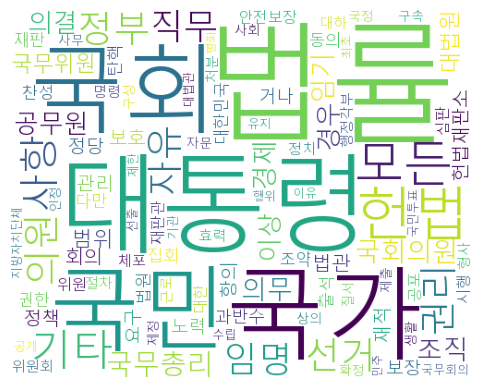

In [58]:
import matplotlib.pyplot as plt
plt.imshow(wc_img)
plt.axis("off")
plt.show()